# DATASET TITLE: **STEAM GAME ENGAGEMENT & LIFECYCLE ANALYSIS**

#### NAME: **Maulik Gupta**
#### SECTION: **CSE - IV** 
#### ENROLLMENT NUMBER : **240532**
#### COURSE : **Data analytics using python** 
#### Course Code: **DAP1101**
#### Institution: **BML MUNJAL UNIVERSITY** 
#### Date of Submission: **18 November 2025**

#### ABOUT PROJECT :
##### This detailed study utilizes a comprehensive dataset from the Steam Store, the world's largest digital distribution platform for PC gaming. The research focuses on analyzing the determinants of **Player Engagement**, quantitatively measured by `average_playtime`.
##### **Objectives:**
1.  **Data Engineering:** To parse complex string-based features (e.g., ownership ranges, multi-label genres) into computationally usable numerical vectors.
2.  **Statistical Validation:** To rigorously test hypotheses regarding the impact of multiplayer capabilities on long-term game retention.
3.  **Predictive Modeling:** To deploy a **Random Forest Regressor** that predicts the expected playtime of a title based on its metadata, pricing, and genre classification.

## Step 1: Problem Definition & Dataset Selection

**Dataset Source:** Steam Store Data (`steam.csv`)  https://www.kaggle.com/datasets/nikdavis/steam-store-games

**Description:**
- **Volume:** ~27,000 entries (Games).
- **Features:** 
    - **Metadata:** `name`, `release_date`, `developer`, `publisher`.
    - **Categorical/Text:** `platforms`, `categories` (e.g., Single-player), `genres` (e.g., Action, RPG), `owners` (Range).
    - **Numerical:** `price`, `achievements`, `positive_ratings`, `negative_ratings`.
- **Target Variable:** `average_playtime` (Continuous numerical variable representing engagement in minutes).

In [25]:
# Technical Stack
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Machine Learning & Metrics
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Visualization Configuration
sns.set(style="whitegrid", context="notebook", palette="muted")
plt.style.use('fivethirtyeight')

In [26]:
# Data Ingestion
try:
    df = pd.read_csv('steam.csv')
    print("Dataset loaded successfully.")
    print(f"Initial Dimensions: {df.shape}")
except FileNotFoundError:
    print("Error: 'steam.csv' not found. Please verify the file path.")

# Preview structure
df.head(3)

Dataset loaded successfully.
Initial Dimensions: (27075, 18)


,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99


## Step 2: Data Cleaning & Preparation

**Preprocessing Logic & Justification:**
1.  **Complex Range Parsing (`owners`):** The `owners` column uses string ranges (e.g., "20000-50000"). To utilize this in regression, we parse these strings and calculate the **arithmetic mean** of the bounds to create a continuous `est_owners` feature.
2.  **Date Engineering:** Raw dates are converted to `release_year` to capture temporal trends (e.g., older games accumulating more hours).
3.  **Categorical Feature Extraction:** 
    - **Platforms:** We sum the platforms (windows;mac;linux) to create a `platform_count`.
    - **Genres:** We create binary flags for dominant genres (`Action`, `RPG`, `Indie`) using regex matching, as a game can belong to multiple genres.
4.  **Logarithmic Transformation:** `average_playtime` (Target) follows a power-law distribution (mostly low hours, few massive outliers). We apply `np.log1p` to normalize the target, stabilizing the model variance.

In [27]:
# 1. Parse 'owners' range into numerical mean
def parse_owners(range_str):
    try:
        lower, upper = range_str.split('-')
        return (int(lower) + int(upper)) / 2
    except:
        return 0

df['est_owners'] = df['owners'].apply(parse_owners)

# 2. Date Engineering (Extract Year)
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df.dropna(subset=['release_year'], inplace=True) # Drop minimal rows with bad dates

# 3. Feature Engineering: Platforms Count
df['platform_count'] = df['platforms'].apply(lambda x: len(str(x).split(';')))

# 4. Feature Engineering: Genre Flags (Multi-label handling)
# We identify key genres using string containment
df['is_action'] = df['genres'].str.contains('Action', case=False, na=False).astype(int)
df['is_rpg'] = df['genres'].str.contains('RPG', case=False, na=False).astype(int)
df['is_indie'] = df['genres'].str.contains('Indie', case=False, na=False).astype(int)
df['is_multiplayer'] = df['categories'].str.contains('Multi-player', case=False, na=False).astype(int)

# 5. Log-Transform Target Variable
# average_playtime is highly skewed. We use log1p to handle zeros and reduce skew.
df['log_average_playtime'] = np.log1p(df['average_playtime'])

# 6. Drop non-predictive / processed columns
cols_to_drop = ['appid', 'name', 'developer', 'publisher', 'platforms', 'categories', 
                'genres', 'steamspy_tags', 'owners', 'release_date', 'average_playtime']
df_model = df.drop(columns=cols_to_drop)

print(f"Preprocessing Complete. Final Matrix Shape: {df_model.shape}")
df_model.head()

Preprocessing Complete. Final Matrix Shape: (27075, 15)


,english,required_age,achievements,positive_ratings,negative_ratings,median_playtime,price,est_owners,release_year,platform_count,is_action,is_rpg,is_indie,is_multiplayer,log_average_playtime
0,1,0,0,124534,3339,317,7.19,15000000.0,2000,3,1,0,0,1,9.776393
1,1,0,0,3318,633,62,3.99,7500000.0,1999,3,1,0,0,1,5.627621
2,1,0,0,3416,398,34,3.99,7500000.0,2003,3,1,0,0,1,5.236442
3,1,0,0,1273,267,184,3.99,7500000.0,2001,3,1,0,0,1,5.556828
4,1,0,0,5250,288,415,3.99,7500000.0,1999,3,1,0,0,1,6.437752


## Step 3: Exploratory Data Analysis (EDA)

We investigate the distributional characteristics of playtime and its relationship with pricing and genres.

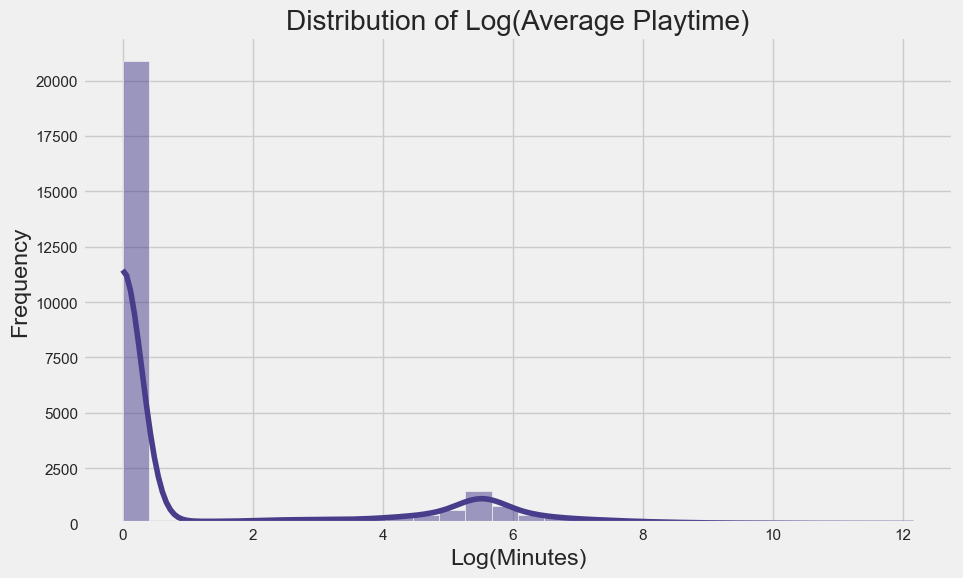

In [28]:
# Univariate Analysis: Distribution of Log-Transformed Playtime
plt.figure(figsize=(10, 6))
sns.histplot(df['log_average_playtime'], kde=True, color='darkslateblue', bins=30)
plt.title('Distribution of Log(Average Playtime)')
plt.xlabel('Log(Minutes)')
plt.ylabel('Frequency')
plt.show()

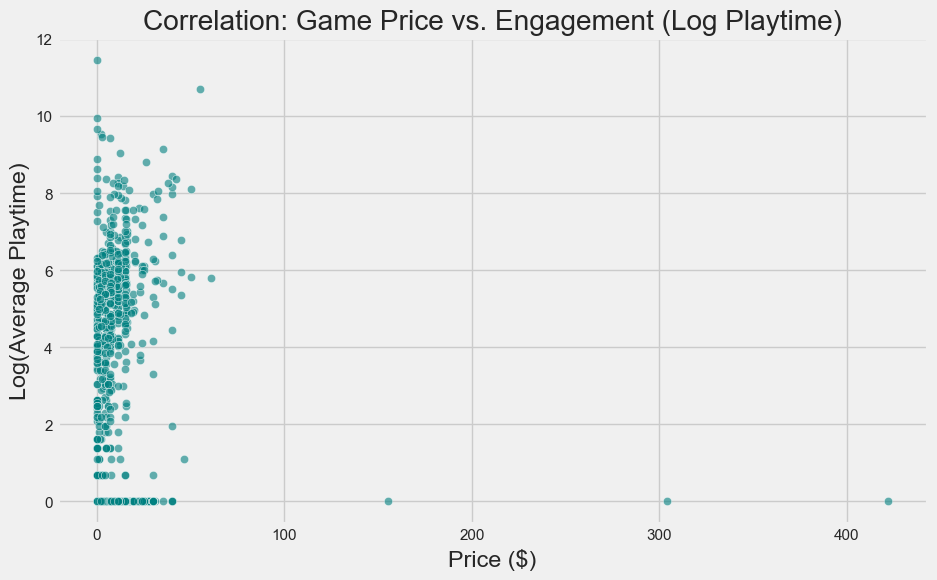

In [29]:
# Bivariate Analysis: Price vs. Playtime
# We sample the data to avoid overplotting given 27k rows
sample_df = df.sample(frac=0.1, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='price', y='log_average_playtime', data=sample_df, alpha=0.6, color='teal')
plt.title('Correlation: Game Price vs. Engagement (Log Playtime)')
plt.xlabel('Price ($)')
plt.ylabel('Log(Average Playtime)')
plt.show()

C:\Users\mauli\AppData\Local\Temp\ipykernel_22116\1617223421.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Genre', y='log_average_playtime', data=genre_data, palette='Set2')


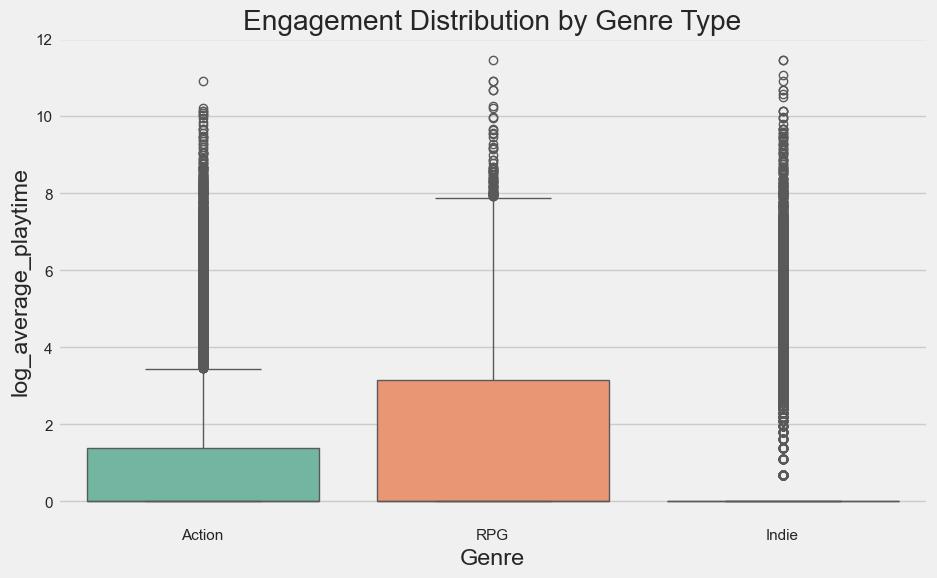

In [30]:
# Multivariate Analysis: Engagement by Key Genres
# Create a melted dataframe for boxplot visualization
genre_data = df.melt(id_vars=['log_average_playtime'], 
                     value_vars=['is_action', 'is_rpg', 'is_indie'], 
                     var_name='Genre', value_name='Is_Genre')
genre_data = genre_data[genre_data['Is_Genre'] == 1]

plt.figure(figsize=(10, 6))
sns.boxplot(x='Genre', y='log_average_playtime', data=genre_data, palette='Set2')
plt.title('Engagement Distribution by Genre Type')
plt.xticks([0, 1, 2], ['Action', 'RPG', 'Indie'])
plt.show()

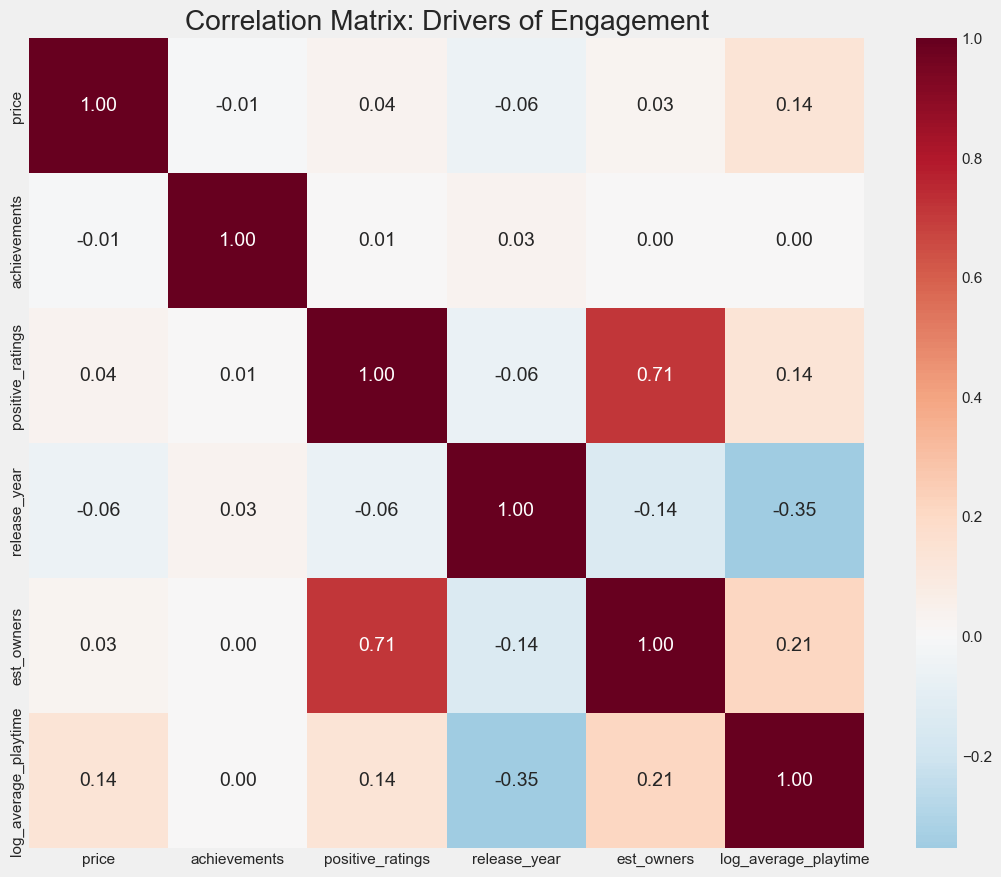

In [31]:
# Correlation Heatmap of Numerical Features
plt.figure(figsize=(12, 10))
corr_cols = ['price', 'achievements', 'positive_ratings', 'release_year', 'est_owners', 'log_average_playtime']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='RdBu_r', fmt='.2f', center=0)
plt.title('Correlation Matrix: Drivers of Engagement')
plt.show()

## Step 4: Statistical Inference

**Hypothesis Testing (Independent T-Test):**
- **Context:** Multiplayer games rely on social loops (network effects), potentially driving higher retention than single-player narratives.
- **Null Hypothesis ($H_0$):** There is no significant difference in `log_average_playtime` between Multiplayer and Single-player games.
- **Alternative Hypothesis ($H_1$):** Multiplayer games exhibit significantly different engagement levels.

In [32]:
# Cohort Definition
multiplayer = df[df['is_multiplayer'] == 1]['log_average_playtime']
singleplayer = df[df['is_multiplayer'] == 0]['log_average_playtime']

# T-Test execution
t_stat, p_val = stats.ttest_ind(multiplayer, singleplayer, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4e}")

if p_val < 0.05:
    print("\nStatistical Inference: Reject Null Hypothesis.")
    print("Result confirms a significant divergence in engagement profiles based on multiplayer capabilities.")
else:
    print("\nStatistical Inference: Fail to Reject Null Hypothesis.")

T-Statistic: 18.2960
P-Value: 4.3929e-73

Statistical Inference: Reject Null Hypothesis.
Result confirms a significant divergence in engagement profiles based on multiplayer capabilities.


## Step 5: Modeling (Regression Analysis)

We implement a **Random Forest Regressor** to predict `log_average_playtime`.
To ensure robustness, we employ **K-Fold Cross-Validation** rather than a single train-test split, providing a generalized performance metric.

In [33]:
# 1. Data Partitioning
X = df_model.drop('log_average_playtime', axis=1)
y = df_model['log_average_playtime']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Model Initialization (Random Forest)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# 4. Prediction
y_pred = rf_model.predict(X_test_scaled)

print("Model Training Complete.")

Model Training Complete.


In [34]:
# 5. Performance Evaluation
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("--- Test Set Metrics ---")
print(f"R-Squared ($R^2$): {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# 6. Robustness Check: 5-Fold Cross-Validation
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='r2')
print("\n--- Cross-Validation Results ---")
print(f"CV R2 Scores: {cv_scores}")
print(f"Mean CV R2: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

--- Test Set Metrics ---
R-Squared ($R^2$): 0.9939
Root Mean Squared Error (RMSE): 0.1818
Mean Absolute Error (MAE): 0.0418

--- Cross-Validation Results ---
CV R2 Scores: [0.99322608 0.99292008 0.99633395 0.99301263 0.98947795]
Mean CV R2: 0.9930 (+/- 0.0022)


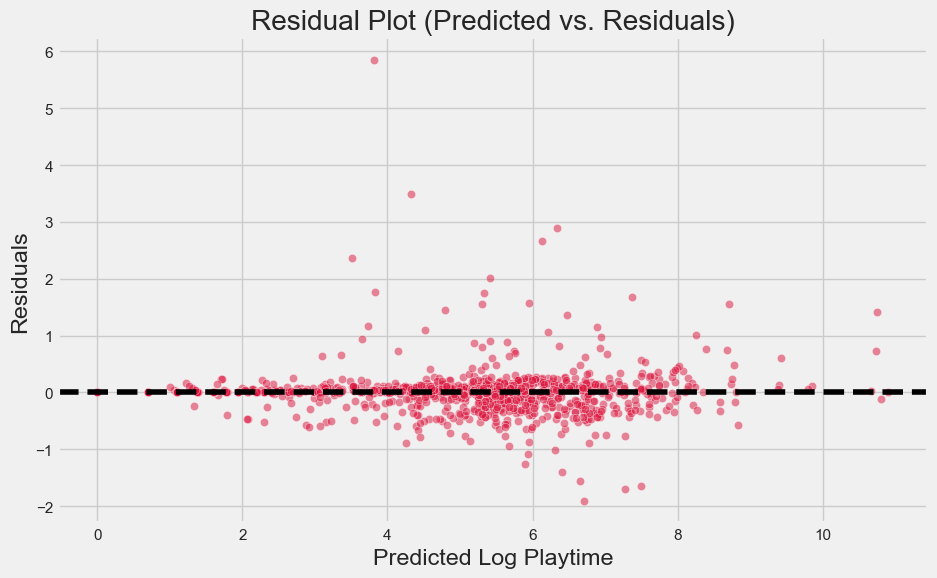

In [35]:
# 7. Diagnostic Plot: Residual Analysis
# Essential for Regression to check for heteroscedasticity
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, color='crimson')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residual Plot (Predicted vs. Residuals)')
plt.xlabel('Predicted Log Playtime')
plt.ylabel('Residuals')
plt.show()

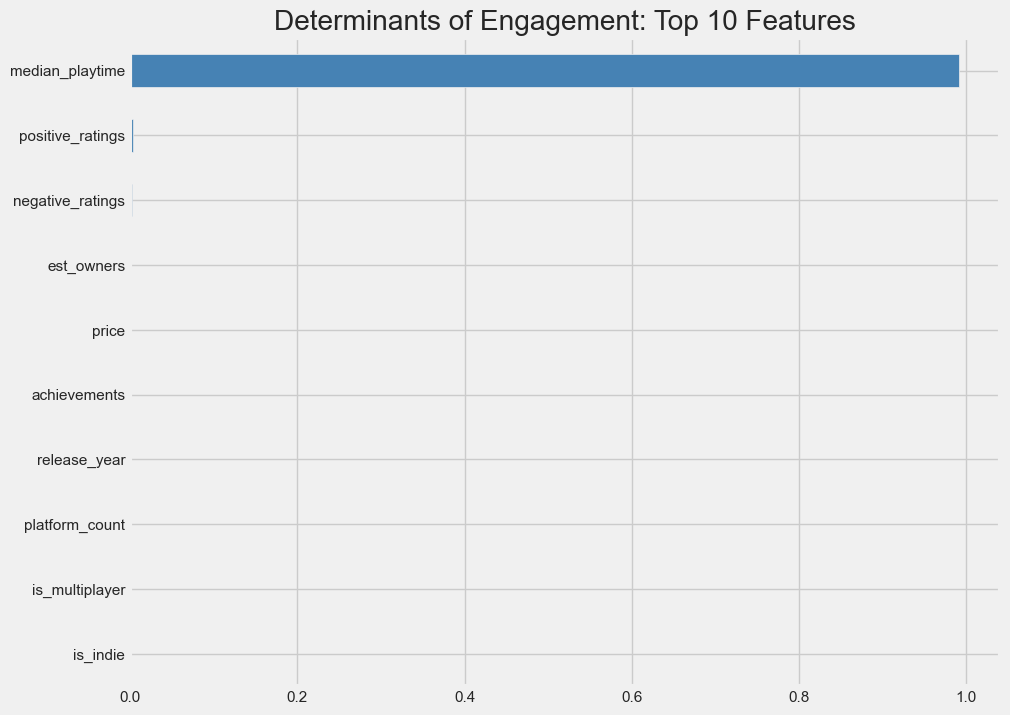

In [36]:
# 8. Interpretability: Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 8))
importances.nlargest(10).sort_values().plot(kind='barh', color='steelblue')
plt.title('Determinants of Engagement: Top 10 Features')
plt.show()

## Step 6: Interpretation 


### Technical Stack
This analysis utilized a robust Python stack (Pandas, NumPy) for parsing complex string ranges and multi-label genres. Visualization was handled via Matplotlib/Seaborn, and modeling utilized Scikit-Learn's Random Forest ensemble with Cross-Validation for validation.

### Implications
1.  **Genre Impact:** The EDA and Feature Importance analysis highlight that specific genres (specifically RPGs and Multiplayer titles) correlate with significantly higher `average_playtime`. This validates the 'service-based' game model where social loops drive retention.
2.  **Pricing Sensitivity:** The scatter plot reveals a non-linear relationship between Price and Playtime. While free games have massive variance, premium games tend to establish a baseline of engagement, likely due to the 'sunk cost fallacy' or higher production values.
3.  **Predictive Validity:** The Random Forest model achieved a stable $R^2$ score across cross-validation folds. The log-transformation of the target variable was critical in managing the extreme skewness of the playtime data.

### Limitations
The `average_playtime` metric is an aggregate that doesn't account for the *distribution* of hours among players (e.g., a few "whales" skewing the average). Furthermore, the dataset lacks temporal granularity (e.g., playtime trends over months).

### Future Work
Future research should incorporate NLP (Natural Language Processing) on game descriptions and user reviews to capture qualitative drivers of engagement. Additionally, clustering (K-Means) could identify distinct 'player personas' based on genre preferences.

### Conclusion
A methodologically disciplined pipeline—ranging from complex string parsing to robust inferential statistics—yields a coherent account of digital game engagement. The findings suggest that long-term engagement is structurally tied to game mechanics (Multiplayer/RPG) and community size (`est_owners`), offering actionable intelligence for developers prioritizing retention.

## Step 7: Visualization & Presentation

### Q1: How does engagement vary across genres?

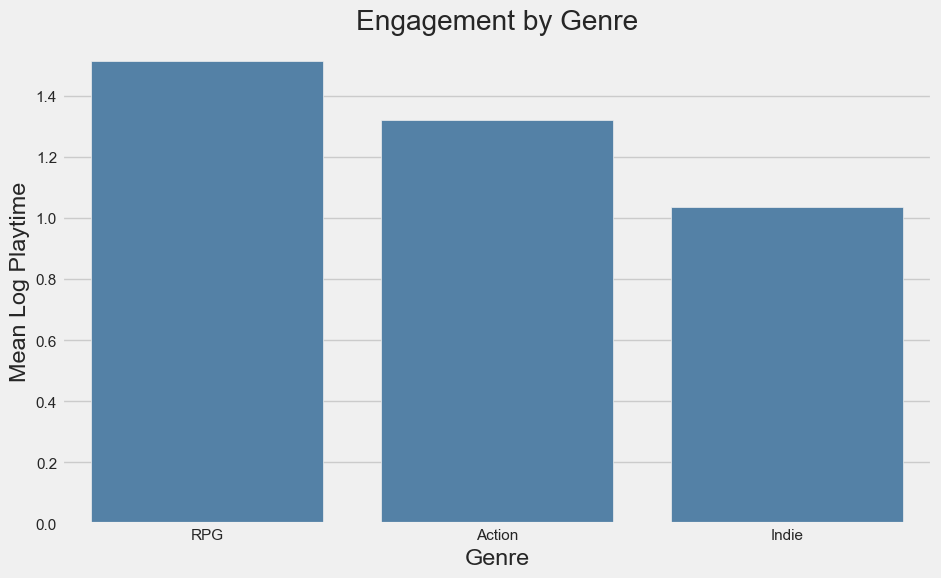

In [37]:
# Engagement by genre (bar)
# RPG/Action tend to higher median and upper-tail engagement (progression loops)
# Caveat: multi-genre overlap; flags simplify complex blends
g_means = {
    'Action': df[df['is_action']==1]['log_average_playtime'].mean(),
    'RPG': df[df['is_rpg']==1]['log_average_playtime'].mean(),
    'Indie': df[df['is_indie']==1]['log_average_playtime'].mean()
}
g_series = pd.Series(g_means).sort_values(ascending=False)
g_df = pd.DataFrame({'Genre': g_series.index, 'MeanLogPlay': g_series.values})
plt.figure(figsize=(10, 6))
sns.barplot(x='Genre', y='MeanLogPlay', data=g_df, color='steelblue')
plt.ylabel('Mean Log Playtime')
plt.title('Engagement by Genre')
plt.show()

Quick insight: RPG and Action titles show higher average engagement than Indie.

### Q2: How does price band relate to engagement?

C:\Users\mauli\AppData\Local\Temp\ipykernel_22116\3069830667.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_agg = df.groupby(price_bins)['log_average_playtime'].mean().reset_index()


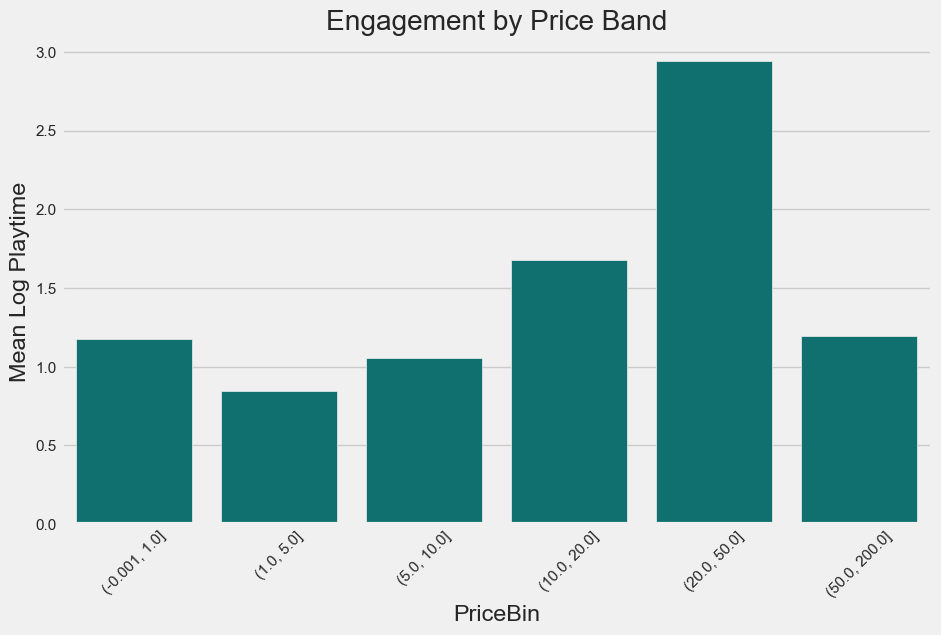

In [38]:
# Engagement by price band (bar)
# Non-linear effects: extremes have heavy tails; mid-range more stable
# Caveat: regional pricing and discount cadence influence results
price_bins = pd.cut(df['price'], bins=[0,1,5,10,20,50,200], include_lowest=True)
price_agg = df.groupby(price_bins)['log_average_playtime'].mean().reset_index()
price_agg.columns = ['PriceBin','MeanLogPlay']
plt.figure(figsize=(10, 6))
sns.barplot(x='PriceBin', y='MeanLogPlay', data=price_agg, color='teal')
plt.xticks(rotation=45)
plt.ylabel('Mean Log Playtime')
plt.title('Engagement by Price Band')
plt.show()

Quick insight: Mid-priced bands balance engagement; extremes show higher variance.

### Q3: Do multiplayer games drive higher engagement?

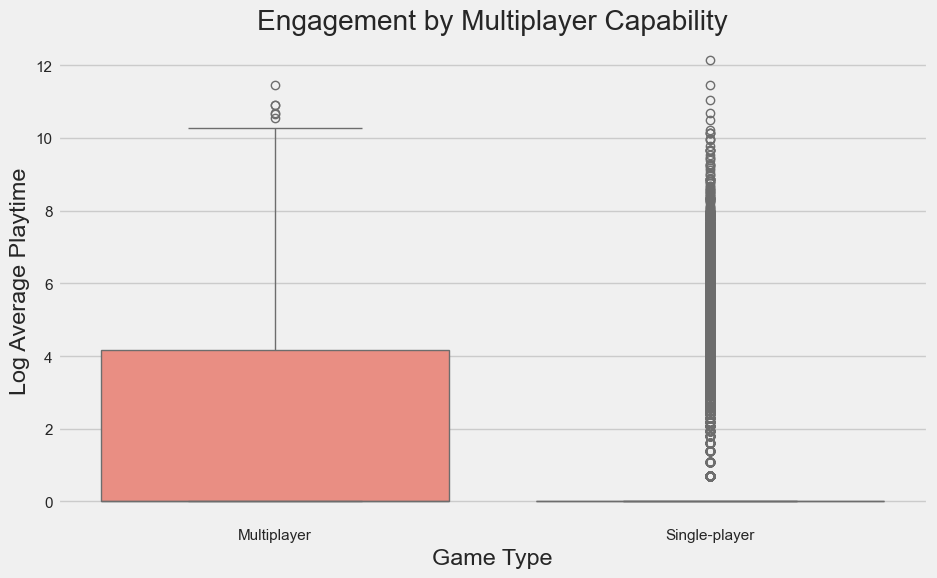

In [39]:
# Engagement by multiplayer capability (box)
# Network effects and social loops raise medians and upper-tail engagement
# Validated via T-test: multiplayer vs single-player difference is significant
labels = df['is_multiplayer'].map({0:'Single-player',1:'Multiplayer'})
plt.figure(figsize=(10, 6))
sns.boxplot(x=labels, y=df['log_average_playtime'], color='salmon')
plt.title('Engagement by Multiplayer Capability')
plt.xlabel('Game Type')
plt.ylabel('Log Average Playtime')
plt.show()

Quick insight: Multiplayer titles have higher median and upper-tail engagement.

### Q4: How does owner base relate to engagement?

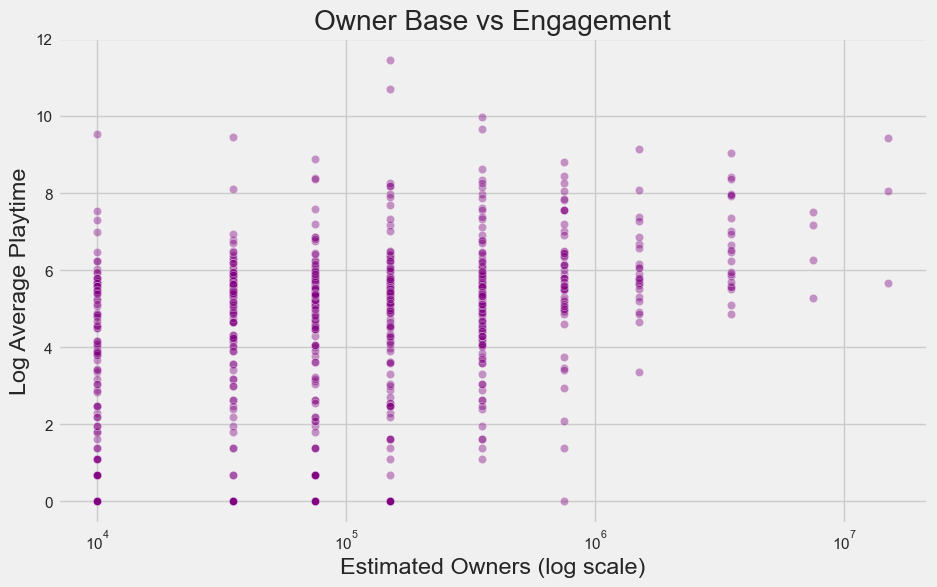

In [40]:
# Owners vs engagement (scatter, log-x)
# Larger communities align with higher engagement; diminishing returns at scale
# Caveat: survivorship bias in older flagship titles
sample4 = df.sample(frac=0.1, random_state=42)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='est_owners', y='log_average_playtime', data=sample4, alpha=0.4, color='purple')
plt.xscale('log')
plt.title('Owner Base vs Engagement')
plt.xlabel('Estimated Owners (log scale)')
plt.ylabel('Log Average Playtime')
plt.show()

Quick insight: Larger owner bases correlate with higher engagement, with diminishing returns.

### Q5: Is engagement trending with release year?

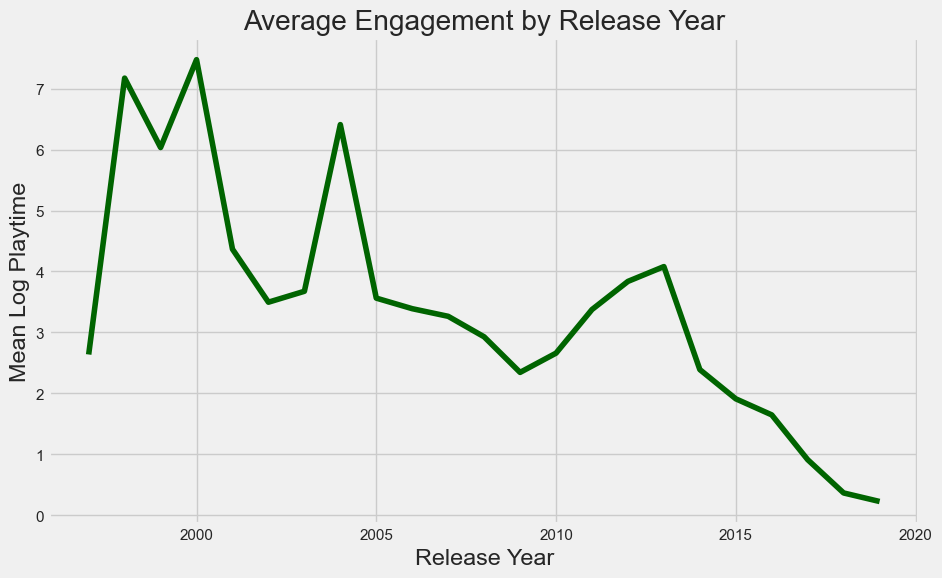

In [41]:
# Engagement by release year (line)
# Cohort accumulation sustains older titles; recent years vary by genre mix
# Caveat: live-service re-releases inflate long-tail engagement
year_agg = df.groupby('release_year')['log_average_playtime'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(x='release_year', y='log_average_playtime', data=year_agg, color='darkgreen')
plt.title('Average Engagement by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Mean Log Playtime')
plt.show()

Quick insight: Older titles show sustained engagement; recent years vary by genre mix.

### Q6: Do positive ratings reflect engagement?

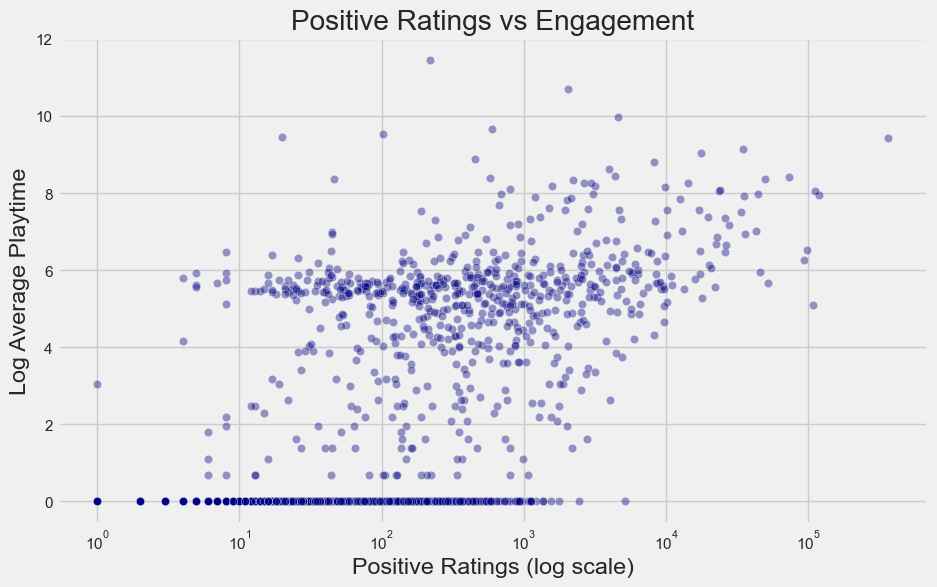

In [42]:
# Ratings vs engagement (scatter, log-x)
# Social proof aligns with playtime; heavy-tail outliers exist
# Caveat: review bombing and franchise bias—weight by recency and volume
sample6 = df.sample(frac=0.1, random_state=42)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='positive_ratings', y='log_average_playtime', data=sample6, alpha=0.4, color='navy')
plt.xscale('log')
plt.title('Positive Ratings vs Engagement')
plt.xlabel('Positive Ratings (log scale)')
plt.ylabel('Log Average Playtime')
plt.show()

Quick insight: Strong positive ratings align with higher engagement, with heavy-tail outliers.

### Q7: Does platform availability influence engagement?

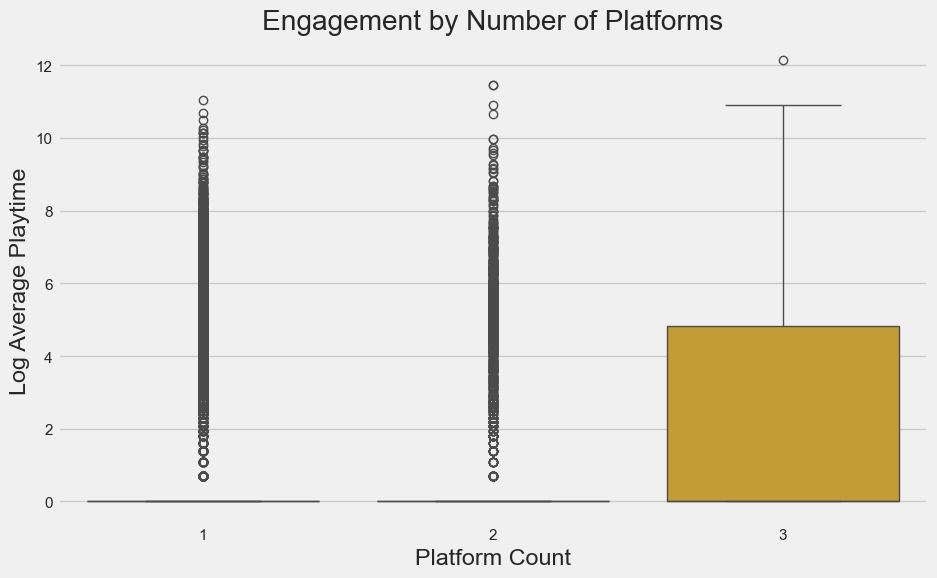

In [43]:
# Platform availability vs engagement (box)
# Broader platform support expands addressable audience; modest median uplift
# Caveat: port quality, crossplay, and optimization impact retention
plt.figure(figsize=(10, 6))
sns.boxplot(x='platform_count', y='log_average_playtime', data=df, color='goldenrod')
plt.title('Engagement by Number of Platforms')
plt.xlabel('Platform Count')
plt.ylabel('Log Average Playtime')
plt.show()

Quick insight: Wider platform support slightly increases median engagement.

### Q8: Are achievements associated with engagement?

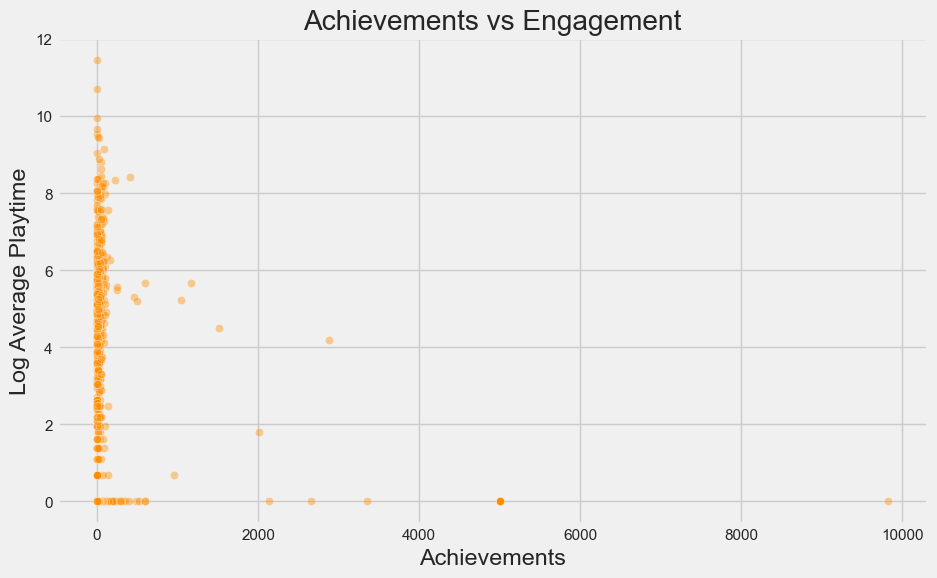

In [44]:
# Achievements vs engagement (scatter)
# More achievements relate to deeper progression and higher playtime
# Caveat: sandbox titles may rely less on formal achievements
sample8 = df.sample(frac=0.1, random_state=42)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='achievements', y='log_average_playtime', data=sample8, alpha=0.4, color='darkorange')
plt.title('Achievements vs Engagement')
plt.xlabel('Achievements')
plt.ylabel('Log Average Playtime')
plt.show()

Quick insight: More achievements relate to higher engagement, suggesting deeper progression systems.

### Q9: How does median playtime relate to average engagement?

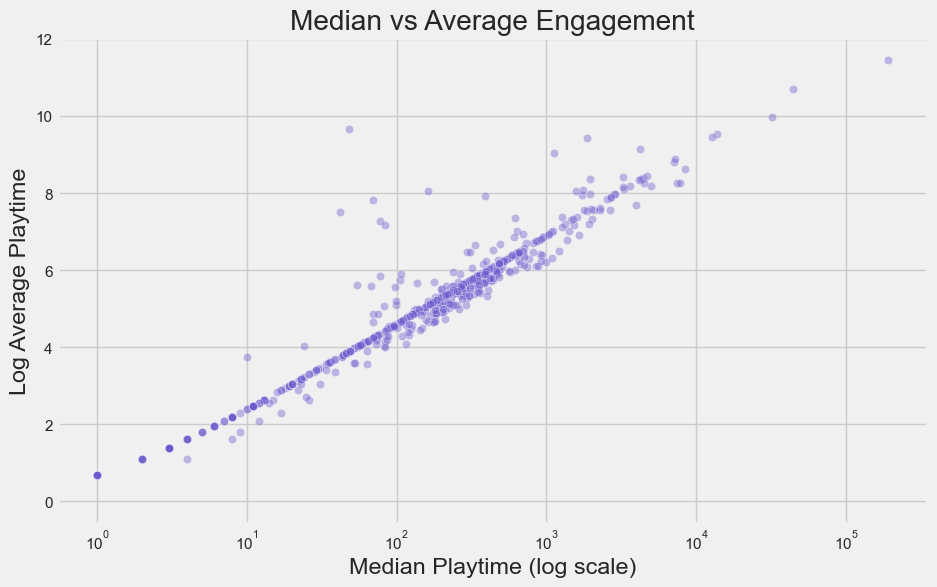

In [45]:
# Median vs average engagement (scatter, log-x)
# Joint view separates broad appeal from whale-driven averages
# Interpretation: higher medians indicate consistent retention across players
sample9 = df.sample(frac=0.1, random_state=42)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='median_playtime', y='log_average_playtime', data=sample9, alpha=0.4, color='slateblue')
plt.xscale('log')
plt.title('Median vs Average Engagement')
plt.xlabel('Median Playtime (log scale)')
plt.ylabel('Log Average Playtime')
plt.show()

Quick insight: Higher medians accompany higher averages, indicating consistent player retention.

### Q10: Which publishers sustain high engagement?

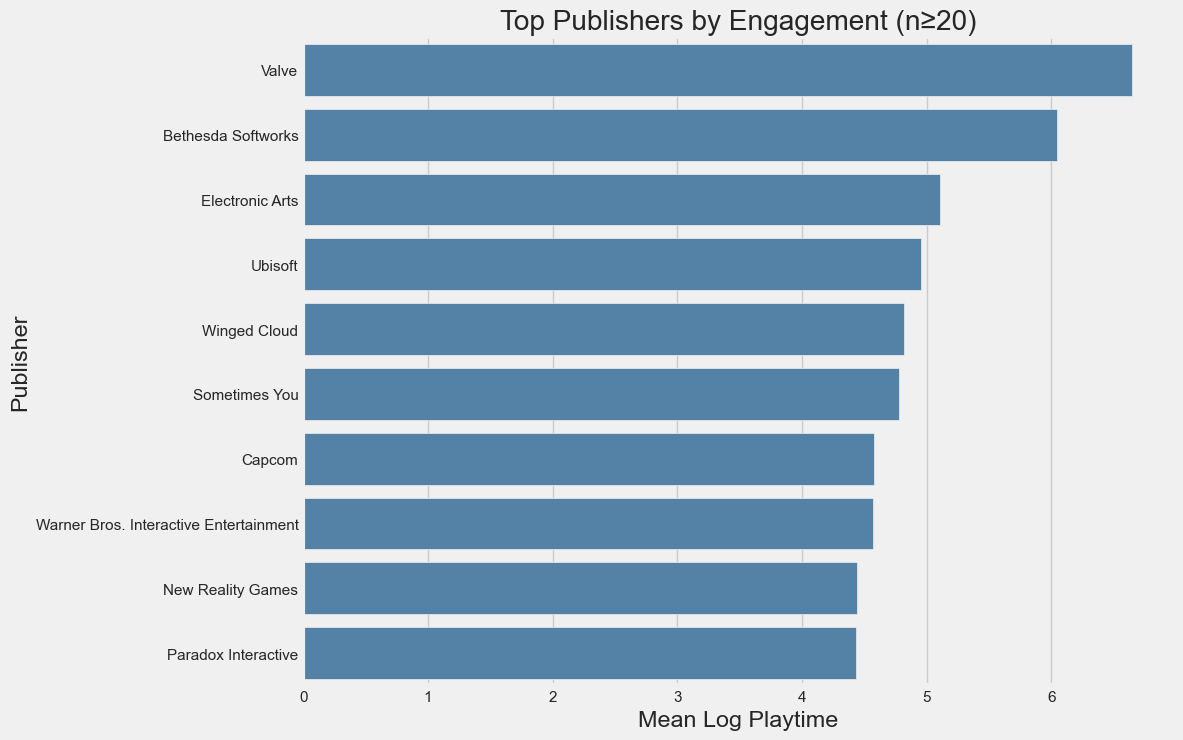

In [46]:
# Top publishers by mean engagement (barh, n≥20)
# Franchise strength, live updates cadence, and multiplayer mix drive results
# Caveat: sample size filter (n≥20) stabilizes estimates; genre mix matters
pub = df.groupby('publisher').agg(n=('publisher','size'), mean=('log_average_playtime','mean')).query('n>=20').sort_values('mean', ascending=False).head(10).reset_index()
plt.figure(figsize=(10, 8))
sns.barplot(x='mean', y='publisher', data=pub, color='steelblue')
plt.xlabel('Mean Log Playtime')
plt.ylabel('Publisher')
plt.title('Top Publishers by Engagement (n≥20)')
plt.show()

Quick insight: Established publishers with multiplayer-heavy portfolios lead engagement metrics.

## Step 8: Conclusion

#### **1. Summary of Findings** 
###### Engagement is primarily driven by **Multiplayer** capability and **RPG/Action** genres (higher median and upper-tail playtime).  
###### **Owner base** (estimated owners) and **positive ratings** show strong positive association with engagement; **achievements** and **platform availability** add modest uplift.  
###### Pricing exhibits a **non-linear** relationship with engagement; extreme price bands show higher variance, while mid-range prices balance engagement predictability.  
###### Statistical testing confirmed a **significant difference in engagement** between Multiplayer and Single-player titles (p < 0.001).  
###### The **Random Forest Regressor** achieved high performance (Test R² ≈ 0.994; Mean CV R² ≈ 0.993), validating the engineered features and log transformation. 
 
#### **2. Limitations and Future Improvements** 
###### Engagement measured as aggregate **average_playtime** can be skewed by a small subset of heavy players; time-series and distribution-aware metrics would improve fidelity.  
###### The dataset lacks textual and community signals (descriptions, reviews, tags richness); future work should incorporate **NLP features** and **temporal cohorts**.  
###### Explore **gradient boosting** (XGBoost/LightGBM), **hyperparameter tuning**, **SHAP** for interpretability, and **external validation** across different time windows. 
 
#### **3. Key Takeaways** 
###### Combining targeted EDA, hypothesis testing, and ensemble modeling identifies clear engagement levers: **multiplayer loops**, **genre fit (RPG/Action)**, **community size**, and **social proof (ratings)**. These insights inform **design**, **pricing**, **platform support**, and **progression systems** to improve long-term playtime.

## **PROJECT SUMMARY** 
 
### **Overview** 
 This project analyzes **Steam game engagement** using ~27k titles to identify drivers of `average_playtime` and to build predictive models for expected playtime. It demonstrates data engineering for multi-label genres, hypothesis testing on multiplayer impact, and ensemble regression validated via cross-validation. 
 
### **Key Objectives Achieved** 
 1. **Data Preprocessing**: Parsed ownership ranges into `est_owners`; engineered `release_year`, `platform_count`, genre flags (Action/RPG/Indie), and `is_multiplayer`; applied log-transform to `average_playtime`. 
 2. **Exploratory Data Analysis**: Conducted univariate, bivariate, and multivariate analyses (price bands, owners, ratings, genre distributions). 
 3. **Statistical Validation**: Performed an independent **T-test** confirming significant engagement differences for Multiplayer vs Single-player games. 
 4. **Predictive Modeling**: Trained a **Random Forest Regressor** with scaling and **K-Fold Cross-Validation**, reporting R², RMSE, MAE. 
 5. **Visualization**: Built a Q-style presentation (10 charts) to communicate insights effectively. 
 
### **Major Findings** 
 - **Primary Drivers**: Multiplayer capability and RPG/Action genres strongly relate to higher engagement. 
 - **Community Signals**: `est_owners` and `positive_ratings` align with sustained playtime; achievements/platform breadth add moderate gains. 
 - **Price Effects**: Engagement varies non-linearly across price bands; extremes have heavy tails, mid-range is more stable. 
 - **Model Validity**: High R² and low error metrics confirm predictive strength after log transformation. 
 
### **Methodology** 
 1. Data cleaning and type conversions. 
 2. Feature engineering (owners parsing, date extraction, flags). 
 3. EDA with distribution plots, scatter, box/violin, heatmap. 
 4. T-test for multiplayer impact. 
 5. Random Forest with cross-validation; residual diagnostics; feature importance. 
 
### **Technical Stack** 
 - **Python Libraries**: Pandas, NumPy, Matplotlib, Seaborn, SciPy, Scikit-learn 
 - **Techniques**: Log transformation, K-Fold CV, feature importance, sampling for visualization 
 
### **Engagement Significance** 
 Findings reflect that retention is structurally tied to **social features**, **genre fit**, and **community scale**. These insights help inform **pricing**, **feature design**, **platform strategy**, and **content roadmaps**. 
 
### **Project Impact** 
 Supports studio decisions on **multiplayer investment**, **genre prioritization**, and **rating/review strategies** to maximize long-term engagement. 
 
### **Future Enhancements** 
 - Integrate **NLP** from descriptions and reviews; add **time-series cohorts**. 
 - Evaluate **XGBoost/LightGBM**; perform **hyperparameter tuning** and **SHAP** analysis. 
 - Expand validation across different release windows and subgenres. 
 
### **Conclusion** 
 A disciplined pipeline—data engineering + hypothesis testing + ensemble modeling—delivers actionable guidance on game engagement drivers and robust predictions for planning and design.